In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install -qq langchain-groq langchain-community langchain-core langgraph

### LLM Setup

In [3]:
from kaggle_secrets import UserSecretsClient
from langchain_groq import ChatGroq

# Securely fetch the key from Kaggle's secret storage
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GROQ_API_KEY")

llm = ChatGroq(
    model='llama-3.3-70b-versatile',
    api_key=api_key
)

# Non LLM Based Workflow

In [24]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

### Define State and Functions

In [26]:
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category : str

In [27]:
def calculate_bmi(state : BMIState) -> BMIState :
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2)

    return state

In [28]:
def category(state : BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"

    elif 18.5 <= bmi < 25:
        state["category"] = "Normal weight"

    elif 25 <= bmi < 30:
        state["category"] = "Overweight"

    else:
        state["category"] = "Obese"

    return state

### Define Graph - Add nodes - Add edges

In [29]:
#graph
graph = StateGraph(BMIState)

#nodes
graph.add_node('calculate_bmi',calculate_bmi) #node name,func name
graph.add_node('category',category)

#add edges
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'category')
graph.add_edge('category',END)

#compile graph
workflow = graph.compile()

In [30]:
#execute graph
input_state = {'weight_kg':61, 'height_m':1.73}
output_state = workflow.invoke(input_state)
print(output_state)

{'weight_kg': 61, 'height_m': 1.73, 'bmi': 20.38, 'category': 'Normal weight'}


### Visualize Graph

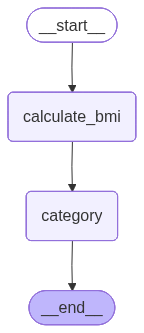

In [31]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

# LLM Baesd Workflow

In [32]:
class QAGenerator(TypedDict):
    topic : str
    que_type : str
    que : str

In [41]:
def generate_question(state : QAGenerator) -> QAGenerator:
    prompt = f"""You are a Question generator. 
    Based on the given topic you have to generate a question of given type.
    Topic : {state['topic']}
    Question Type : {state['que_type']}
    """

    question = llm.invoke(prompt)
    state['que'] = question.content

    return state

In [42]:
graph = StateGraph(QAGenerator)

graph.add_node('generate_question',generate_question)

graph.add_edge(START,'generate_question')
graph.add_edge('generate_question',END)

flow = graph.compile()

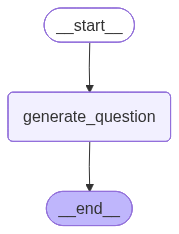

In [43]:
Image(flow.get_graph().draw_mermaid_png())

In [48]:
input_state = {'topic':'LSTM','que_type':'MCQ'}
output_state = flow.invoke(input_state)
for key,val in output_state.items():
    print(f"\n{key}:{val}")


topic:LSTM

que_type:MCQ

que:Here's a Multiple Choice Question (MCQ) on the topic of LSTM:

What is the primary function of the "forget gate" in a Long Short-Term Memory (LSTM) network?

A) To add new information to the cell state
B) To determine the output of the LSTM cell
C) To decide what information to discard from the previous cell state
D) To control the flow of information from the input gate to the output gate

Choose the correct answer.


In [49]:
input_state = {'topic':'Chemistry Hydrocarbons','que_type':'Fill in the blanks'}
output_state = flow.invoke(input_state)
for key,val in output_state.items():
    print(f"\n{key}:{val}")


topic:Chemistry Hydrocarbons

que_type:Fill in the blanks

que:Here's a fill-in-the-blank question based on the topic "Chemistry Hydrocarbons":

The general formula for _______ hydrocarbons is CnH2n+2, where 'n' represents the number of carbon atoms in the molecule.
